# Asymmetric Clausius Quarkyonic EOS

This notebook computes the quarkyonic EOS using the asymmetric Clausius parameters extracted in the `nuclear_matter_workflows` package.

Reference workflow: `QM-isos-CS-TVM-fit-and-run.ipynb`

Assumption used here:

- the Clausius attraction in the hadronic sector is
  `-[a_n (n_p^2+n_n^2) + 2 a_pn n_p n_n] / (1 + c n_h)`
- with `n_h = n_p + n_n = rho_B (1-f_q)` the hadronic baryon density

This keeps the quarkyonic extension consistent with the asymmetric baryonic interaction picture used in the fit.


In [1]:
from dataclasses import asdict
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

repo_root = Path("/Users/dajuarez4/Documents/QuarkMatt/nuclear_matter_workflows")
src_path = repo_root / "asymmetric_clausius_fit" / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from asymmetric_clausius_fit import (
    DEFAULT_CONSTANTS,
    DEFAULT_K0_TARGETS,
    MP,
    RHO0,
    build_quarkyonic_eos_objects,
    compute_target_family,
    convert_fit_df_to_gev_units,
    default_rhob_list,
    default_y_values,
    save_fixed_y_tables,
)

pd.set_option("display.precision", 6)

results_dir = repo_root / "results"
results_dir.mkdir(parents=True, exist_ok=True)
output_dir = results_dir / "asymmetric_clausius_quarkyonic_outputs"
output_dir.mkdir(parents=True, exist_ok=True)

# Running all fitted K0 branches is possible, but it is slower.
# Use DEFAULT_K0_TARGETS here if you want the full family.
ACTIVE_TARGET_K0S = [250.0, 280.0, 315.0]

# Moderate defaults so the notebook stays runnable.
BETA_RHOB_LIST = default_rhob_list(n_points=30)
FIXED_Y_RHOB_LIST = default_rhob_list(n_points=60)
Y_VALUES = default_y_values()

EOS_NINT = 120
BETA_Y_SCAN = 40
FQ_MIN = 1.0e-3
FQ_MAX = 1.0

output_dir


PosixPath('/Users/dajuarez4/Documents/QuarkMatt/nuclear_matter_workflows/results/asymmetric_clausius_quarkyonic_outputs')

## Load or recompute the asymmetric Clausius fit


In [2]:
fit_csv = results_dir / "asymmetric_clausius_fit_results.csv"
if fit_csv.exists():
    fit_df = pd.read_csv(fit_csv)
else:
    fit_df = pd.DataFrame(asdict(result) for result in compute_target_family(DEFAULT_K0_TARGETS, DEFAULT_CONSTANTS))
    fit_df.to_csv(fit_csv, index=False)

fit_df = fit_df.sort_values("target_k0").reset_index(drop=True)
display(fit_df[["target_k0", "c", "a_avg", "b_avg", "a_n", "a_pn", "b_n", "b_pn", "J", "L"]])


,target_k0,c,a_avg,b_avg,a_n,a_pn,b_n,b_pn,J,L
0,250.0,4.735853,472.327508,1.727371,259.413733,685.241282,1.316923,2.137819,32.5,58.9
1,260.0,4.516312,466.026019,1.800838,256.197399,675.854639,1.351272,2.250404,32.5,58.9
2,270.0,4.309453,460.064473,1.870418,253.177802,666.951144,1.384757,2.356079,32.5,58.9
3,280.0,4.114108,454.412697,1.936450,250.336526,658.488869,1.417423,2.455476,32.5,58.9
4,290.0,3.929255,449.044178,1.999231,247.657454,650.430902,1.449313,2.549149,32.5,58.9
5,300.0,3.753994,443.935490,2.059026,245.126408,642.744572,1.480464,2.637588,32.5,58.9
6,310.0,3.587529,439.065850,2.116069,242.730858,635.400842,1.510911,2.721226,32.5,58.9
7,315.0,3.507371,436.714809,2.143624,241.580371,631.849247,1.525881,2.761368,32.5,58.9


In [3]:
fit_df_gev = convert_fit_df_to_gev_units(fit_df)
active_fit_df = fit_df_gev[fit_df_gev["target_k0"].isin(ACTIVE_TARGET_K0S)].copy()

display(
    active_fit_df[[
        "target_k0",
        "a_n_gev", "a_pn_gev",
        "b_n_gev", "b_pn_gev",
        "c_gev",
    ]]
)


,target_k0,a_n_gev,a_pn_gev,b_n_gev,b_pn_gev,c_gev
0,250.0,33.762419,89.183417,171.396119,278.234862,616.366159
3,280.0,32.581030,85.701619,184.476114,319.577591,535.446754
7,315.0,31.441426,82.234501,198.591755,359.389024,456.480621


## Build the EOS objects


In [4]:
eos_map = build_quarkyonic_eos_objects(fit_df, target_k0_values=ACTIVE_TARGET_K0S, nint=EOS_NINT)
list(eos_map.keys())


['k0_250', 'k0_280', 'k0_315']

## Beta equilibrium + charge neutrality


In [5]:
beta_results = {}
beta_summary_rows = []

for label, eos in eos_map.items():
    df = eos.beta_equilibrium_profile(
        BETA_RHOB_LIST,
        fq_min=FQ_MIN,
        fq_max=FQ_MAX,
        tol=1.0e-6,
        y_scan=BETA_Y_SCAN,
    )
    beta_results[label] = df
    df.to_csv(output_dir / f"beta_profile_{label}.csv", index=False)

    rho0_idx = (df["rhob"] - RHO0).abs().idxmin()
    beta_summary_rows.append(
        {
            "label": label,
            "target_k0": eos.target_k0,
            "fq_at_rho0": df.loc[rho0_idx, "fq_star"],
            "y_at_rho0": df.loc[rho0_idx, "y_star"],
            "mu_e_at_rho0": df.loc[rho0_idx, "mu_e"],
            "vs2_max": df["vs2"].max(),
        }
    )

beta_summary_df = pd.DataFrame(beta_summary_rows)
beta_summary_csv = results_dir / "asymmetric_clausius_quarkyonic_beta_summary.csv"
beta_summary_df.to_csv(beta_summary_csv, index=False)
display(beta_summary_df)
beta_summary_csv


,label,target_k0,fq_at_rho0,y_at_rho0,mu_e_at_rho0,vs2_max
0,k0_250,250.0,0.001,0.052783,0.121245,2.071422
1,k0_280,280.0,0.001,0.053113,0.121433,2.012222
2,k0_315,315.0,0.001,0.053481,0.121643,1.699918


PosixPath('/Users/dajuarez4/Documents/QuarkMatt/nuclear_matter_workflows/results/asymmetric_clausius_quarkyonic_beta_summary.csv')

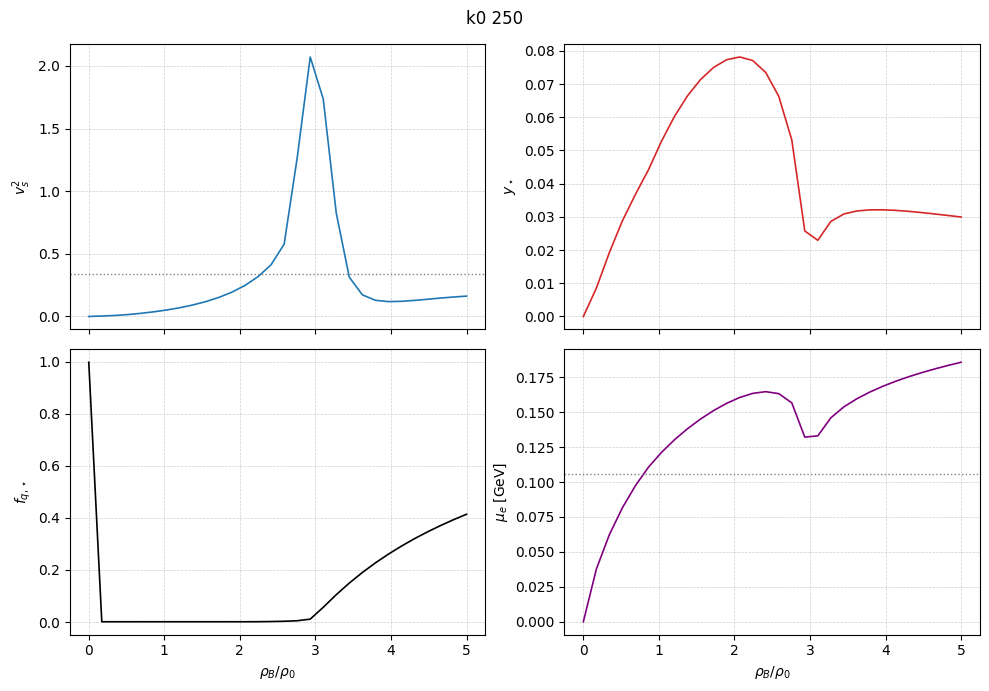

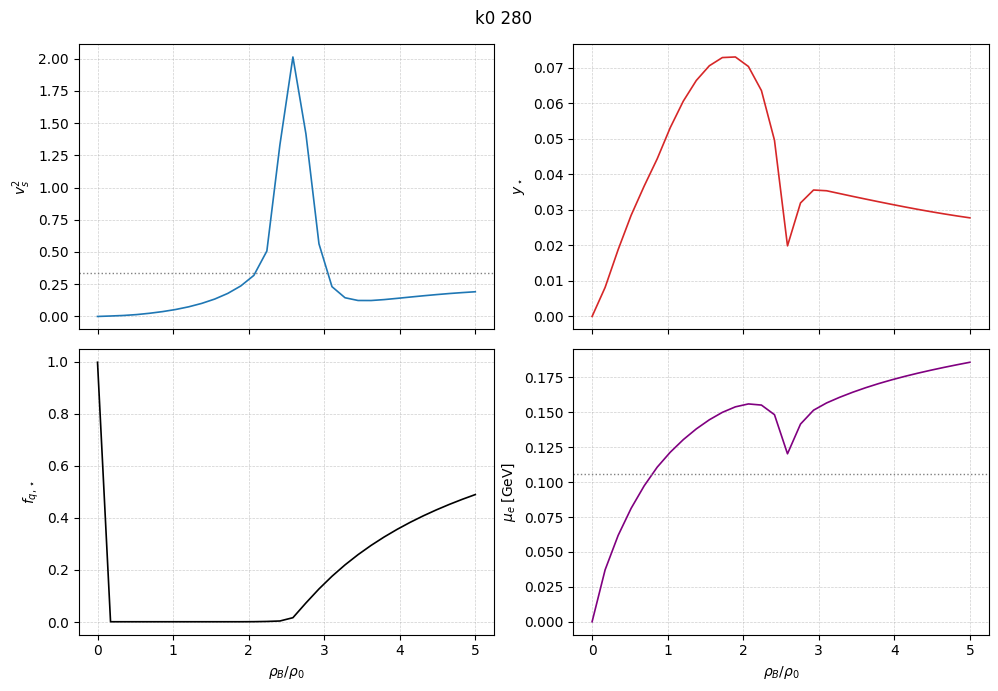

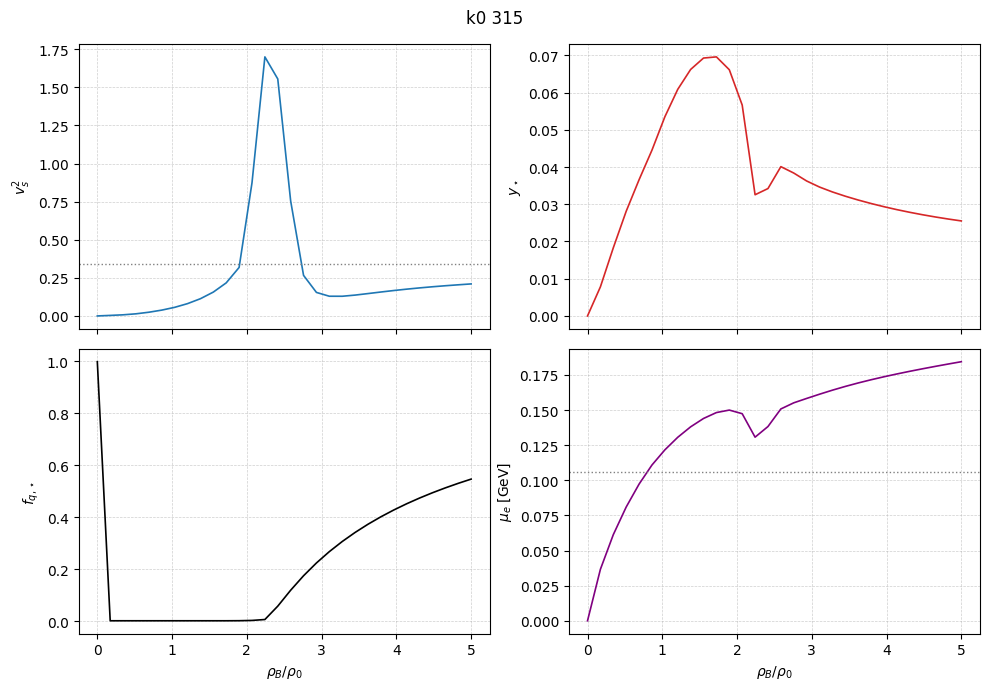

In [6]:
for label, df in beta_results.items():
    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
    fig.suptitle(label.replace("_", " "))

    axes[0, 0].plot(df["rho_over_rho0"], df["vs2"], color="tab:blue", lw=1.2)
    axes[0, 0].axhline(0.34, color="0.5", ls=":", lw=1.0)
    axes[0, 0].set_ylabel(r"$v_s^2$")

    axes[0, 1].plot(df["rho_over_rho0"], df["y_star"], color="tab:red", lw=1.2)
    axes[0, 1].set_ylabel(r"$y_\star$")

    axes[1, 0].plot(df["rho_over_rho0"], df["fq_star"], color="black", lw=1.2)
    axes[1, 0].set_xlabel(r"$\rho_B/\rho_0$")
    axes[1, 0].set_ylabel(r"$f_{q,\star}$")

    axes[1, 1].plot(df["rho_over_rho0"], df["mu_e"], color="purple", lw=1.2)
    axes[1, 1].axhline(0.10566, color="0.5", ls=":", lw=1.0)
    axes[1, 1].set_xlabel(r"$\rho_B/\rho_0$")
    axes[1, 1].set_ylabel(r"$\mu_e$ [GeV]")

    for ax in axes.ravel():
        ax.grid(True, ls="--", lw=0.5, alpha=0.6)

    plt.tight_layout()
    plt.show()


## Fixed-`y` sweeps and `energy_vs_pressure` tables


In [7]:
fixed_y_results = {}
written_files = []

for label, eos in eos_map.items():
    profile_map = {}
    for y in Y_VALUES:
        profile_map[y] = eos.fixed_y_profile(
            FIXED_Y_RHOB_LIST,
            y=y,
            fq_min=FQ_MIN,
            fq_max=FQ_MAX,
            tol=1.0e-6,
        )
        profile_map[y].to_csv(output_dir / f"fixed_y_profile_{label}_y{y:.1f}.csv", index=False)

    fixed_y_results[label] = profile_map
    written_files.extend(save_fixed_y_tables(profile_map, output_dir, label))

print(f"Wrote {len(written_files)} EOS tables to {output_dir}")
written_files[:8]


Wrote 18 EOS tables to /Users/dajuarez4/Documents/QuarkMatt/nuclear_matter_workflows/results/asymmetric_clausius_quarkyonic_outputs


[PosixPath('/Users/dajuarez4/Documents/QuarkMatt/nuclear_matter_workflows/results/asymmetric_clausius_quarkyonic_outputs/energy_vs_pressure_clausius_k0_250_y0.0.dat'),
 PosixPath('/Users/dajuarez4/Documents/QuarkMatt/nuclear_matter_workflows/results/asymmetric_clausius_quarkyonic_outputs/energy_vs_pressure_clausius_k0_250_y0.1.dat'),
 PosixPath('/Users/dajuarez4/Documents/QuarkMatt/nuclear_matter_workflows/results/asymmetric_clausius_quarkyonic_outputs/energy_vs_pressure_clausius_k0_250_y0.2.dat'),
 PosixPath('/Users/dajuarez4/Documents/QuarkMatt/nuclear_matter_workflows/results/asymmetric_clausius_quarkyonic_outputs/energy_vs_pressure_clausius_k0_250_y0.3.dat'),
 PosixPath('/Users/dajuarez4/Documents/QuarkMatt/nuclear_matter_workflows/results/asymmetric_clausius_quarkyonic_outputs/energy_vs_pressure_clausius_k0_250_y0.4.dat'),
 PosixPath('/Users/dajuarez4/Documents/QuarkMatt/nuclear_matter_workflows/results/asymmetric_clausius_quarkyonic_outputs/energy_vs_pressure_clausius_k0_250_y0.5

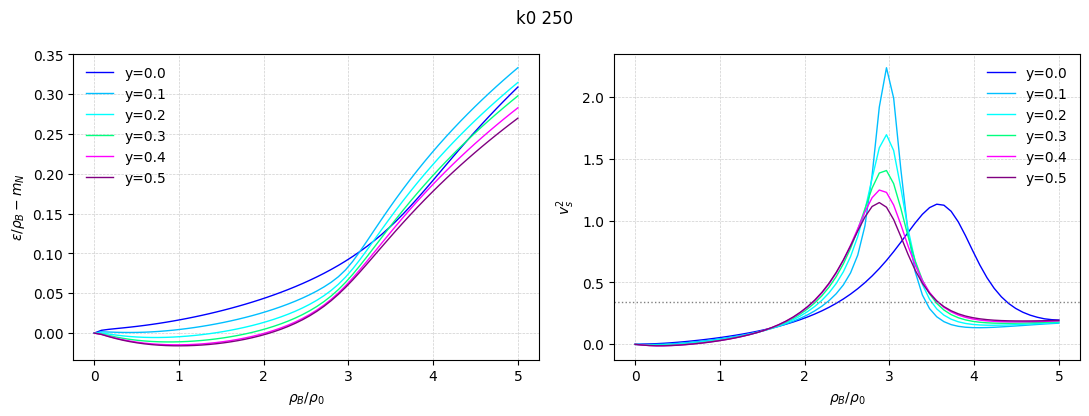

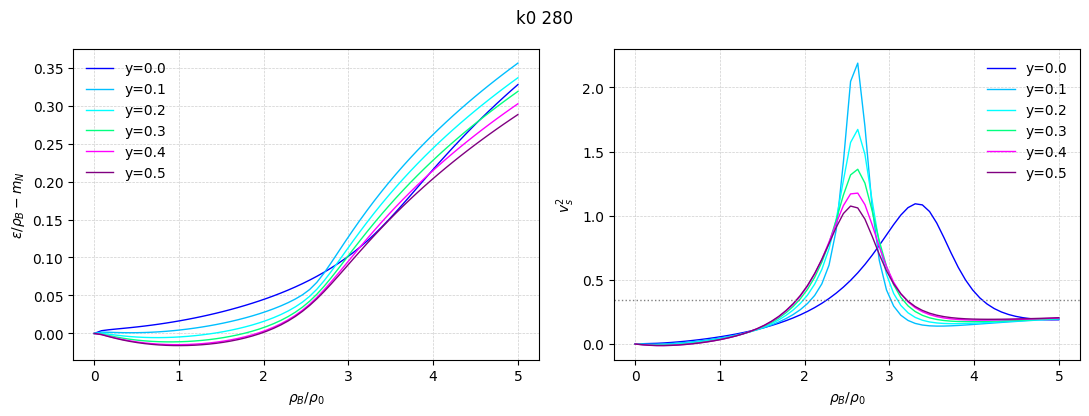

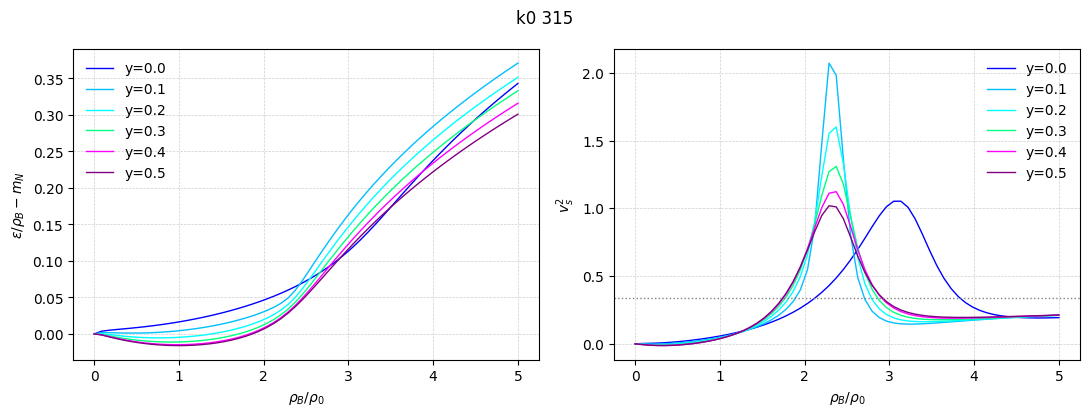

In [8]:
colors = ["blue", "deepskyblue", "cyan", "springgreen", "magenta", "purple"]

for label, profile_map in fixed_y_results.items():
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True)
    fig.suptitle(label.replace("_", " "))

    for color, y in zip(colors, Y_VALUES):
        df = profile_map[y]
        axes[0].plot(
            df["rho_over_rho0"],
            df["energy_density"] / df["rhob"] - MP,
            color=color,
            lw=1.0,
            label=f"y={y:.1f}",
        )
        axes[1].plot(df["rho_over_rho0"], df["vs2"], color=color, lw=1.0, label=f"y={y:.1f}")

    axes[0].set_ylabel(r"$\epsilon / \rho_B - m_N$")
    axes[0].set_xlabel(r"$\rho_B/\rho_0$")
    axes[1].set_ylabel(r"$v_s^2$")
    axes[1].set_xlabel(r"$\rho_B/\rho_0$")
    axes[1].axhline(0.34, color="0.5", ls=":", lw=1.0)

    for ax in axes:
        ax.grid(True, ls="--", lw=0.5, alpha=0.6)
        ax.legend(frameon=False)

    plt.tight_layout()
    plt.show()


## Notes

- The fitted asymmetric Clausius parameters come from `asymmetric_clausius_constraint_analysis.ipynb`.
- To run the full family, replace `ACTIVE_TARGET_K0S` with `list(DEFAULT_K0_TARGETS)`.
- Output files are written to `nuclear_matter_workflows/results/asymmetric_clausius_quarkyonic_outputs/`.
